In [4]:
import cv2
import numpy as np

def create_velocity_tuned_filter(target_vx=0.0, target_vy=0.0,
                                  n_frames=7, spatial_size=5,
                                  spatial_sigma=1.0, temporal_sigma=1.0):
    """
    Create a spatiotemporal Gaussian filter tuned to a specific velocity.

    This filter will keep objects moving at (target_vx, target_vy) sharp
    while blurring objects moving at other velocities.

    Parameters:
    -----------
    target_vx : float
        Target horizontal velocity (pixels/frame)
    target_vy : float
        Target vertical velocity (pixels/frame)
    n_frames : int
        Temporal extent of filter (should be odd)
    spatial_size : int
        Spatial size of filter (should be odd)
    spatial_sigma : float
        Spatial Gaussian sigma
    temporal_sigma : float
        Temporal Gaussian sigma

    Returns:
    --------
    kernel : ndarray (n_frames, spatial_size, spatial_size)
        3D velocity-tuned filter

    Reference:
    ----------
    Adelson & Bergen (1985), "Spatiotemporal energy models for the
    perception of motion." J. Optical Society of America A, 2(2), 284-299.
    """
    # Create coordinate grids
    t_coords = np.arange(n_frames) - n_frames // 2
    x_coords = np.arange(spatial_size) - spatial_size // 2
    y_coords = np.arange(spatial_size) - spatial_size // 2

    T, Y, X = np.meshgrid(t_coords, y_coords, x_coords, indexing='ij')

    # Shift spatial coordinates based on velocity and time
    # This creates the "tilted" Gaussian in spacetime
    X_shifted = X - target_vx * T
    Y_shifted = Y - target_vy * T

    # Create 3D Gaussian
    kernel = np.exp(-(X_shifted**2 + Y_shifted**2) / (2 * spatial_sigma**2) -
                    T**2 / (2 * temporal_sigma**2))

    # Normalize
    kernel = kernel / np.sum(kernel)

    return kernel

# Design filter tuned to fast object velocity (3.0 pixels/frame)
target_velocity = 3.0
motion_filter = create_velocity_tuned_filter(
    target_vx=target_velocity,
    n_frames=7,
    spatial_size=7,
    spatial_sigma=1.5,
    temporal_sigma=1.0
)

def convolve3d(video, kernel):
    """
    Perform 3D convolution on video (space and time).

    Parameters:
    -----------
    video : ndarray (T, H, W)
        Input video
    kernel : ndarray (Kt, Kh, Kw)
        3D convolution kernel

    Returns:
    --------
    output : ndarray
        Filtered video (valid convolution)
    """
    T, H, W = video.shape
    Kt, Kh, Kw = kernel.shape

    # Output dimensions
    out_T = T - Kt + 1
    out_H = H - Kh + 1
    out_W = W - Kw + 1

    output = np.zeros((out_T, out_H, out_W))

    # 3D convolution
    for t in range(out_T):
        for i in range(out_H):
            for j in range(out_W):
                # Extract 3D region
                region = video[t:t+Kt, i:i+Kh, j:j+Kw]
                # Element-wise multiply and sum
                output[t, i, j] = np.sum(region * kernel)

    return output

print("3D convolution function ready!")

3D convolution function ready!


In [5]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture('/content/cctv.mp4')
frames = []

if not cap.isOpened():
    print("Error: Could not open video file. Please check the path and ensure the file exists.")
else:
    while(cap.isOpened()):
        ret, frame = cap.read()
        # I got an error here, so I asked Gemini to help me and it showed that I needed to check ret
        # check if frame was read successfully
        if not ret:
            break
        frame = cv2.resize(frame, (540, 360), fx=0, fy=0)
        # 3D Convolution function requires exact shape of frames to be (T,H,W) so the frames have to be
        # shifted to gray to get it to work properly
        # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = frame / 255
        frames.append(frame)
    cap.release()

video = np.array(frames)


### Blurring Static Background and Emphasizing Motion

To blur static elements and highlight motion, we'll follow these steps:

1.  **Create a Static-Tuned Filter**: A `create_velocity_tuned_filter` with `target_vx=0` (and `target_vy=0`) will act as a low-pass filter in the temporal domain, emphasizing static content.
2.  **Convolve with Static Filter**: Apply this filter to the original video to obtain a version where static objects are preserved and moving objects are blurred.
3.  **Subtract from Original Video**: By subtracting the static-filtered video from the appropriately cropped original video, we effectively emphasize regions of motion and suppress static background. The `convolve3d` function produces an output smaller than the input video, so the original video needs to be cropped to match dimensions for subtraction.
4.  **Normalize and Visualize**: The resulting difference video may contain values outside the typical [0, 1] range for image display. It will be normalized to fit this range for proper visualization.

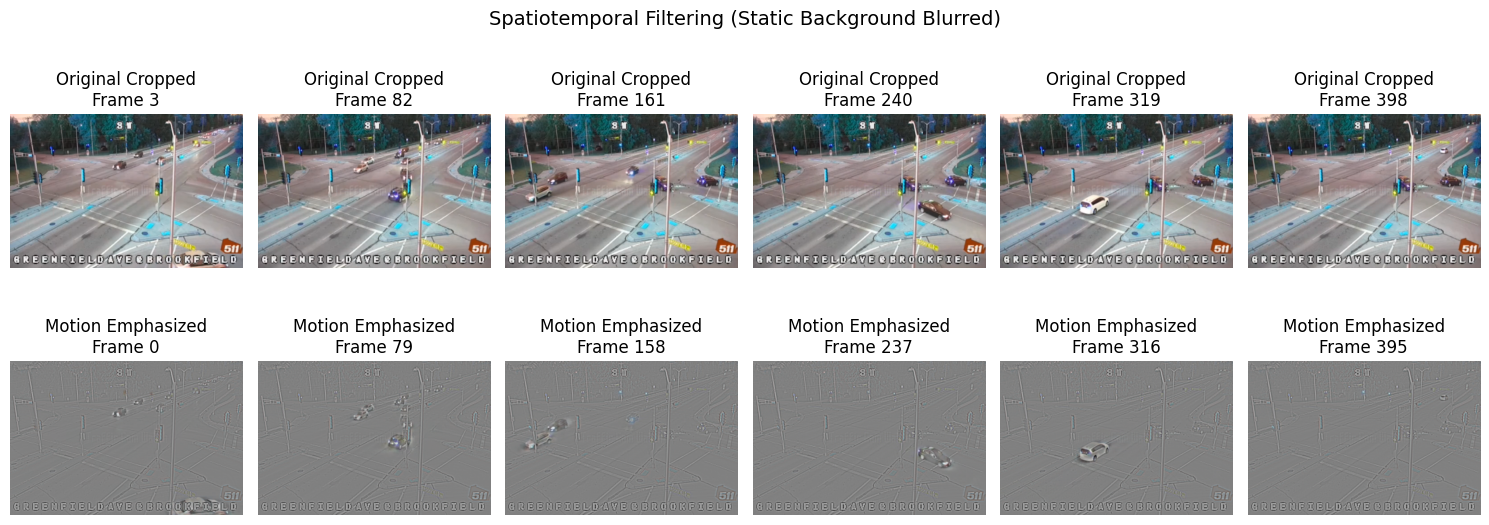

In [6]:
# Ensure video is loaded before proceeding
if video.shape[0] == 0:
    print("Error: No frames were loaded into the video array. Please ensure the video file exists and is readable.")
else:

    is_color = video.ndim == 4 and video.shape[-1] == 3

    static_target_velocity = 0.0
    static_filter = create_velocity_tuned_filter(
        target_vx=static_target_velocity,
        n_frames=7,
        spatial_size=7,
        spatial_sigma=1.5,
        temporal_sigma=1.0
    )

    Kt, Kh, Kw = static_filter.shape

    if is_color:
        filtered_channels_static = []
        for c in range(video.shape[-1]):  # Iterate over color channels
            filtered_channel = convolve3d(video[:, :, :, c], static_filter)
            filtered_channels_static.append(filtered_channel)
        filtered_video_static = np.stack(filtered_channels_static, axis=-1)
    else:
        filtered_video_static = convolve3d(video, static_filter)

    crop_t_start = Kt // 2
    crop_t_end = video.shape[0] - (Kt - 1 - Kt // 2)
    crop_h_start = Kh // 2
    crop_h_end = video.shape[1] - (Kh - 1 - Kh // 2)
    crop_w_start = Kw // 2
    crop_w_end = video.shape[2] - (Kw - 1 - Kw // 2)

    if is_color:
        video_cropped = video[crop_t_start:crop_t_end, crop_h_start:crop_h_end, crop_w_start:crop_w_end, :]
    else:
        video_cropped = video[crop_t_start:crop_t_end, crop_h_start:crop_h_end, crop_w_start:crop_w_end]

    filtered_video_motion = video_cropped - filtered_video_static

    min_val = np.min(filtered_video_motion)
    max_val = np.max(filtered_video_motion)
    if max_val == min_val:
        normalized_filtered_video_motion = np.zeros_like(filtered_video_motion)
    else:
        normalized_filtered_video_motion = (filtered_video_motion - min_val) / (max_val - min_val)

    frame_indices = np.linspace(0, normalized_filtered_video_motion.shape[0]-1, 6, dtype=int)

    fig, axes = plt.subplots(2, 6, figsize=(15, 6))

    for i, frame_idx in enumerate(frame_indices):
        orig_cropped_idx = frame_idx

        axes[0, i].imshow(video_cropped[orig_cropped_idx], vmin=0, vmax=1)
        axes[0, i].set_title(f'Original Cropped\nFrame {orig_cropped_idx + crop_t_start}')
        axes[0, i].axis('off')

        axes[1, i].imshow(normalized_filtered_video_motion[frame_idx], vmin=0, vmax=1)
        axes[1, i].set_title(f'Motion Emphasized\nFrame {frame_idx}')
        axes[1, i].axis('off')

    plt.suptitle(f'Spatiotemporal Filtering (Static Background Blurred)',
                 fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()